<a href="https://colab.research.google.com/github/fcastellanosp/MINE-4206_202410_AML/blob/main/Laboratorios/Laboratorio%204/Sesio%CC%81n_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Contexto y objetivos

### "Los hábitos de consumo y los tarjetahabientes"

La agrupación es una técnica que permite identificar patrones y tendencias en los datos con base en la identificación de grupos o segmentos de objetos con características comunes. Para el caso de una empresa que ofrece el servicio de tarjetas de crédito, la segmentación de clientes le permitiría, por ejemplo, ofrecer productos y servicios adaptados a las características de los grupos identificados, dirigir campañas de marketing a segmentos específicos de clientes y mejorar la experiencia de estos con un servicio de atención personalizado.

Una de tales empresas desea segmentar a sus clientes en función de su comportamiento de compra en centros comerciales con el fin de identificar los diferentes tipos de tarjetahabientes y establecer estrategias de marketing personalizadas para cada uno. Para realizar este estudio se cuenta con datos sobre saldos, límites de crédito y hábitos de compra, entre otros, de una muestra de clientes suministrada por la empresa."

**Objetivos:**
- Realizar el análisis y limpieza de datos
- Realizar la agrupación a través del algoritmo no supervisado.
-

La fuente de datos se puede encontrar [aquí](https://www.kaggle.com/datasets/alifarahmandfar/customer-segmentation).

# Entendimiento del negocio

Para obtener un mejor detalle sobre nuestras variables a utilizar, solicitamos el diccionario de datos que contiene la siguiente información:


| ATRIBUTO | DEFINICIÓN |
| :- | :- |
| **CUST_ID** | Identificador del cliente de la tarjeta de crédito.|
| **BALANCE** | Promedio mensual del saldo (basado en promedios diarios del saldo).|
| **BALANCE_FREQUENCY** | Proporción de los últimos 12 meses con saldo. (1: Actualizado frecuentemente, 0: No actualizado frecuentemente).|
| **PURCHASES** | Monto total de compras realizadas durante los últimos 12 meses.|
| **ONEOFF_PURCHASES** | Monto total de compras únicas.|
| **INSTALLMENTS_PURCHASES** | Monto total de compras a plazos.|
| **CASH_ADVANCE** | Monto total de adelantos de efectivo.|
| **PURCHASES_FREQUENCY** | Frecuencia de compras (Porcentaje de meses con al menos una compra). (1: Compras frecuentes, 0: Compras no frecuentes).|
| **ONEOFF_PURCHASES_FREQUENCY** | Frecuencia de compras únicas. (1: Compras frecuentes, 0: Compras no frecuentes).|
| **PURCHASES_INSTALLMENTS_FREQUENCY** |Frecuencia de compras a plazos. (1: Compras frecuentes, 0: Compras no frecuentes).|
| **CASHADVANCE_FREQUENCY** | Frecuencia de adelantos de efectivo.|
| **CASH_ADVANCE_TRX** | Monto promedio por transacción de adelanto de efectivo.|
| **PURCHASES_TRX** | Monto promedio por transacción de compra.|
| **CREDIT_LIMIT** | Límite de crédito.|
| **PAYMENTS** | Pagos totales (monto adeudado pagado por el cliente para disminuir el saldo de su estado de cuenta) en el período.|
| **MINIMUM_PAYMENTS** | Total de pagos mínimos adeudados en el período.|
| **PRC_FULL_PAYMEN** | Porcentaje de meses con pago completo del saldo adeudado del estado de cuenta.|
| **TENURE** | Número de meses como cliente.|

# 0. Instalación e importación de librerías

In [ ]:
!pip install -q ydata-profiling

In [27]:
import pandas as pd
import numpy as np
import sys
import os
import os.path as osp
import joblib

from sklearn.preprocessing import RobustScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.metrics import silhouette_score, silhouette_samples, rand_score

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# 1. Introducción a los datos

## 1.1. Carga de datos

In [9]:
data = pd.read_csv('Customer_Data.csv')

data

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,5323.148883,0.250693,26344.072201,38237.442525,3727.113162,15708.239684,0.496536,0.464442,0.821611,0.194502,100,77,16819.480037,21337.027458,39452.958121,0.817907,7
1,C10002,12726.638115,0.791307,37958.519019,5690.742440,18733.810964,38284.354433,0.699457,0.250327,0.654863,1.083902,78,156,15617.570575,8000.183624,63013.748477,0.343119,9
2,C10003,4305.572068,0.176531,28392.953338,36009.470088,2873.383232,14294.185035,0.419764,0.523662,0.899912,0.207049,72,81,15515.586213,27111.360493,NaN,0.829074,6
3,C10004,4740.988511,0.178076,27399.003842,38246.863491,3402.853375,6936.812518,0.439666,0.606597,0.783129,0.228299,78,83,12926.587974,23919.113404,38444.219979,0.883984,7
4,C10005,13820.920640,0.826914,42214.021633,7341.007821,19273.070991,40091.347849,0.821412,0.283579,0.501361,1.106350,88,182,14404.705067,6994.688474,62041.617340,0.383186,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C18946,6095.221156,0.234346,27094.007822,35917.204378,3463.821376,11711.578889,0.469832,0.539477,0.828321,0.191030,75,101,17623.810282,23954.396952,34841.829885,0.866856,7
8946,C18947,12682.575822,0.686025,38433.618847,5293.541956,18924.799798,34444.867317,0.710331,0.276426,0.546059,0.935152,95,170,12433.814929,7375.625322,66726.372993,0.306600,10
8947,C18948,16464.311409,0.189136,4296.196384,32554.759639,11231.500433,15214.671563,0.424665,0.746010,0.690380,1.063788,51,151,3307.587117,22947.759217,54761.962206,0.129242,8
8948,C18949,15531.883777,0.117118,12219.325647,31795.971700,12390.432127,13856.393208,0.450670,0.805140,0.608737,1.058548,61,178,6148.232910,21369.503519,50368.309060,0.087448,8


## 1.2. Exploración y preparación de datos

Observamos que todas nuestras variables son numéricas y con rangos muy diferentes. Por lo tanto debemos realizar cierta estandarización a los datos.

In [11]:
# Eliminación de variables poco relevantes
data.drop('CUST_ID', axis=1, inplace=True)

# Verificamos si hay duplicados
print(f'Duplicados: {data.duplicated().sum()}')

# Verificamos si hay datos nulos
print(f'Nulos:\n{data.isna().sum()}')

# Eliminamos los nulos
data.dropna(inplace=True)

Duplicados: 0
Nulos:
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


Revisemos outliers...

In [13]:
# Se calcula el rango intercuartil y se determinan los outliers por variable
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
outliers = ((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR)))
total = outliers.sum()
print(total)

# Número de datos con outliers
datos_outliers = outliers.any(axis=1).sum()
print(f"Número de datos con outliers: {datos_outliers}")

BALANCE                                0
BALANCE_FREQUENCY                      0
PURCHASES                            733
ONEOFF_PURCHASES                       0
INSTALLMENTS_PURCHASES                 0
CASH_ADVANCE                           0
PURCHASES_FREQUENCY                    0
ONEOFF_PURCHASES_FREQUENCY             0
PURCHASES_INSTALLMENTS_FREQUENCY      18
CASH_ADVANCE_FREQUENCY                 0
CASH_ADVANCE_TRX                     239
PURCHASES_TRX                          0
CREDIT_LIMIT                        2108
PAYMENTS                               5
MINIMUM_PAYMENTS                       0
PRC_FULL_PAYMENT                       0
TENURE                                 0
dtype: int64
Número de datos con outliers: 2109


Dada la cantidad de datos se considera entonces no eliminarlos. Acá se puede resaltar que estos datos pueden dar cuenta de algunas caraterísticas interesantes que pueden ayudar en la segmentación.

Entonces estandaricemos!

Para qué? Para evitar que las magnitudes de las variables tengan influencia sobre los algoritmos. En este caso usaremos un `RobustScaler()` que es más robusto que `StandarScaler()` cuando se tienen valores extremos:

In [15]:
robust_scaler = RobustScaler()
scaled_data = robust_scaler.fit_transform(data)
scaled_df = pd.DataFrame(scaled_data, columns=data.columns)
scaled_df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.706404,-0.096365,-0.360201,0.259907,-0.461199,-0.149359,-0.022136,-0.174313,0.721663,-0.943983,0.666667,-0.831933,0.674718,-0.001738,-0.356376,0.804098,-0.333333
1,0.075457,0.855976,0.554035,-0.911285,0.513621,0.746618,0.527013,-0.713970,0.159355,0.170412,-0.148148,-0.168067,0.242031,-0.841000,0.543236,-0.186756,0.333333
2,-0.767884,-0.224286,-0.277162,0.260246,-0.482262,-0.497470,-0.176037,0.183976,0.591893,-0.901636,-0.148148,-0.781513,-0.726723,0.160748,-0.394892,0.941998,-0.333333
3,0.191021,0.918701,0.889008,-0.851900,0.548651,0.818332,0.857051,-0.630162,-0.358285,0.198539,0.222222,0.050420,-0.194601,-0.904274,0.506117,-0.103139,0.666667
4,0.045087,0.706886,0.767803,-0.894535,0.556992,0.514631,0.898597,-0.478037,-0.269085,0.028564,0.777778,0.336134,-0.140526,-0.789773,0.360487,-0.071436,0.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8631,-0.624868,-0.125160,-0.301170,0.176413,-0.478302,-0.307974,-0.094401,0.014804,0.744291,-0.948332,-0.259259,-0.630252,0.964277,0.162969,-0.532440,0.906252,-0.333333
8632,0.070804,0.670512,0.591432,-0.925578,0.526027,0.594241,0.556441,-0.648191,-0.207554,-0.015968,0.481481,-0.050420,-0.904121,-0.880302,0.684994,-0.262969,0.666667
8633,0.470182,-0.204803,-2.095708,0.055416,0.026279,-0.168947,-0.216634,0.535351,0.279126,0.145210,-1.148148,-0.210084,-4.189564,0.099623,0.228162,-0.633106,0.000000
8634,0.371711,-0.331669,-1.472036,0.028111,0.101562,-0.222853,-0.146259,0.684382,0.003808,0.138643,-0.777778,0.016807,-3.166931,0.000306,0.060401,-0.720327,0.000000


Además, para poder realizar un análisis de los clústeres resultantes con mayor facilidad, vamos a almacenar el objeto robust_scaler para deshacer la estandarización cuando sea necesario:

In [17]:
joblib.dump(robust_scaler, 'robust_scaler.joblib')

['robust_scaler.joblib']

# 2. Modelamiento

Para cumplir el primer objetivo, utilizamos un aprendizaje no supervisado, ya que lo que queremos es obtener las características que resumen los datos. En este caso se puede utilizar el algoritmo de K-Means.

Sin embargo, para que nuestro algoritmo pueda funcionar, necesitamos definirle cuál va a ser la cantidad de grupos que va a ejecutar. Además, K-Means es muy sensible a las condiciones iniciales...

In [19]:
def buscar_modelo(k, semilla):
    print(f"Entrenando el modelo con k={k} y semilla={semilla}.")
    model = KMeans(n_clusters=k,random_state=semilla, init='random', n_init=1)
    model.fit(data)

    return model.inertia_

In [21]:
candidatos = [9,22,33,42,50]
grupos = range(2,10)
distorsions = dict()

for semilla in candidatos:
    distorsions[semilla] = list()
    for k in grupos:
        inertia = buscar_modelo(k, semilla)
        distorsions[semilla].append(inertia)
        print("Score:",inertia)
        print('-'*50)

Entrenando el modelo con k=2 y semilla=9.
Score: 2566476121585.6133
--------------------------------------------------
Entrenando el modelo con k=3 y semilla=9.
Score: 995755882423.4615
--------------------------------------------------
Entrenando el modelo con k=4 y semilla=9.
Score: 975743930926.9708
--------------------------------------------------
Entrenando el modelo con k=5 y semilla=9.
Score: 970496324664.6796
--------------------------------------------------
Entrenando el modelo con k=6 y semilla=9.
Score: 406287949517.0494
--------------------------------------------------
Entrenando el modelo con k=7 y semilla=9.
Score: 353523159634.13275
--------------------------------------------------
Entrenando el modelo con k=8 y semilla=9.
Score: 301141449282.2555
--------------------------------------------------
Entrenando el modelo con k=9 y semilla=9.
Score: 286859629597.49567
--------------------------------------------------
Entrenando el modelo con k=2 y semilla=22.
Score: 256

### 2.1. Búsqueda del hiperparámetro K: Método del Codo

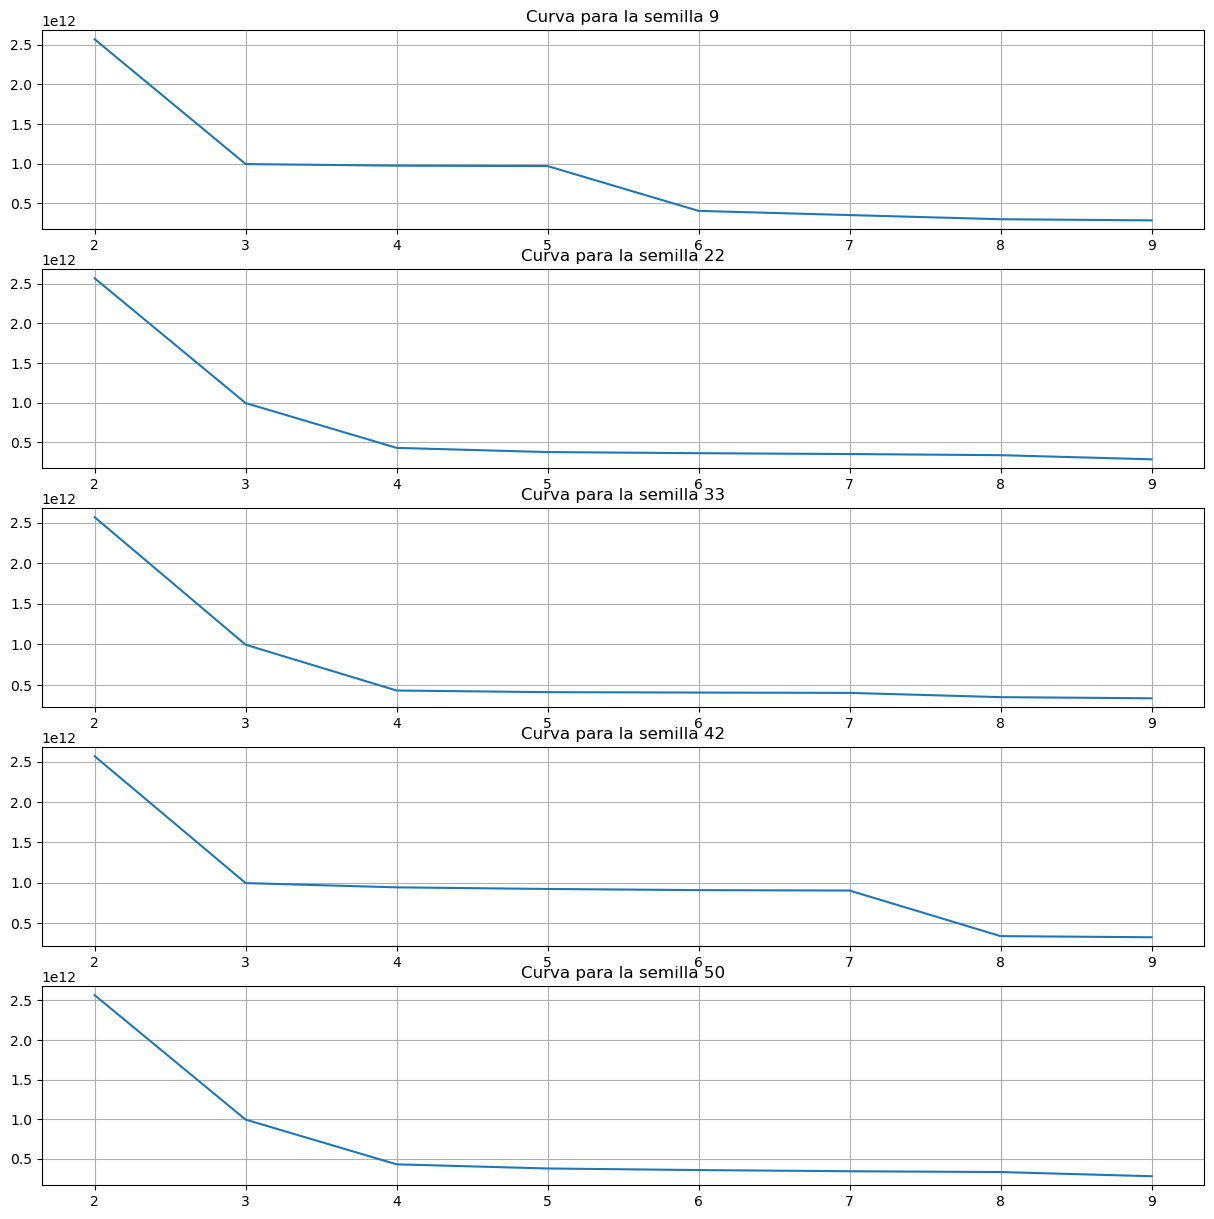

In [23]:
fig = plt.figure(figsize=(15, 15))

for i, sem in enumerate(candidatos):
    ax = plt.subplot(len(candidatos), 1, i + 1)
    plt.plot(grupos, distorsions[sem])
    plt.grid(True)
    plt.title(f'Curva para la semilla {sem}')
plt.show()

A pesar de que vemos una gran disminución en `k=3`, en algunos casos de las diferentes semillas nuestro valor óptimo es `k=4` ya que después de este es cuando se tiene un comportamiento aproximadamente lineal.

**Verifiquémoslo con el método de la silueta.**

### 2.2. Búsqueda del hiperparámetro K: Método de la silueta

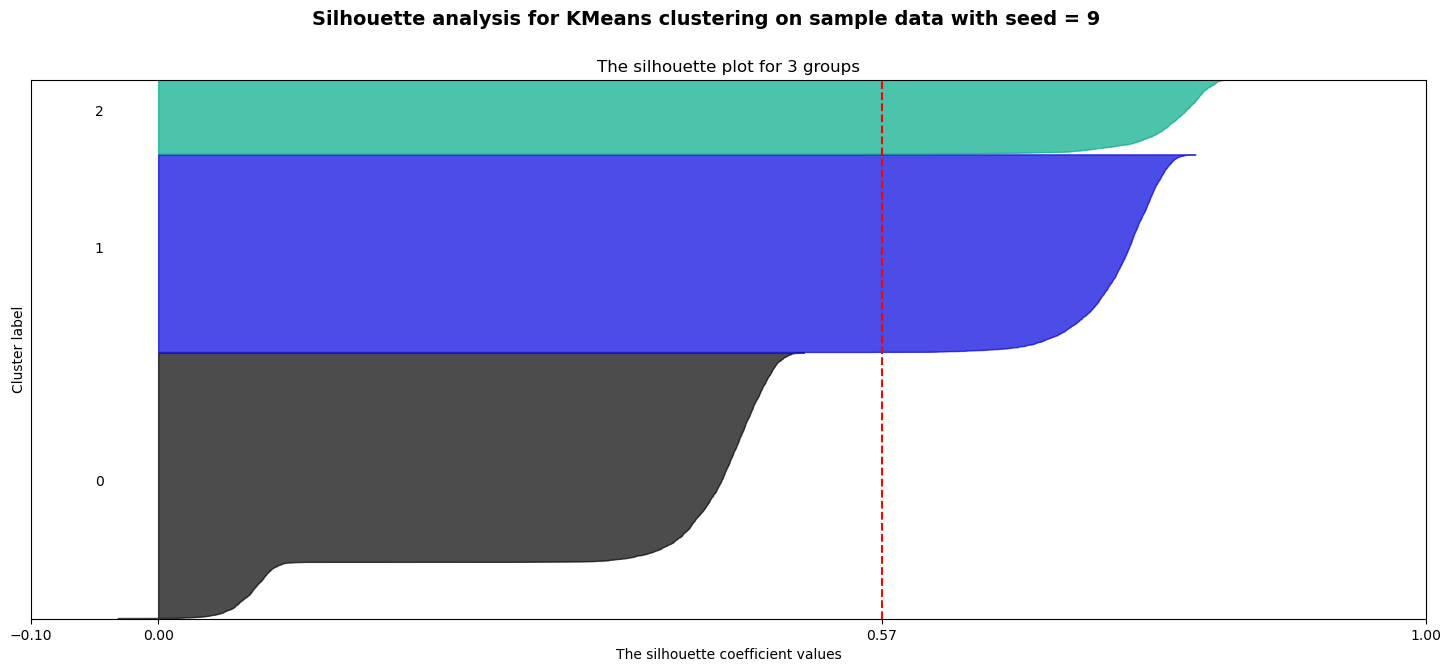

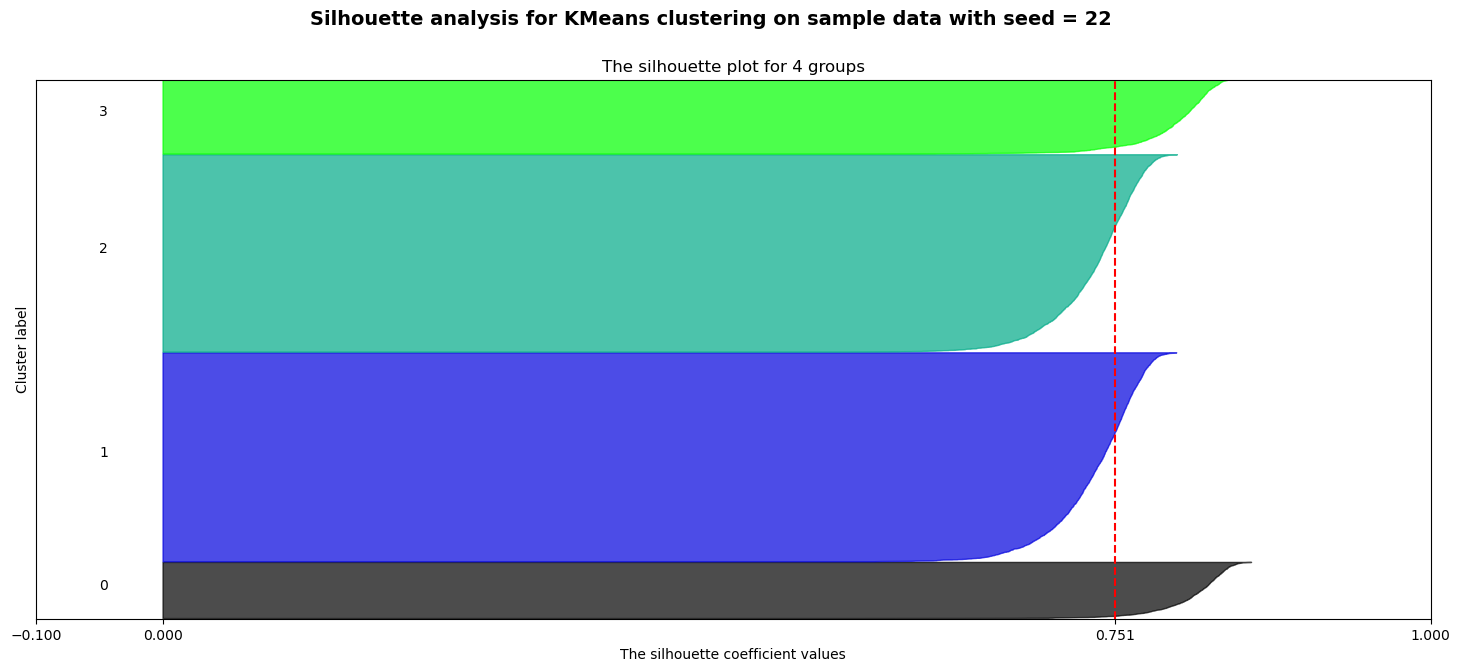

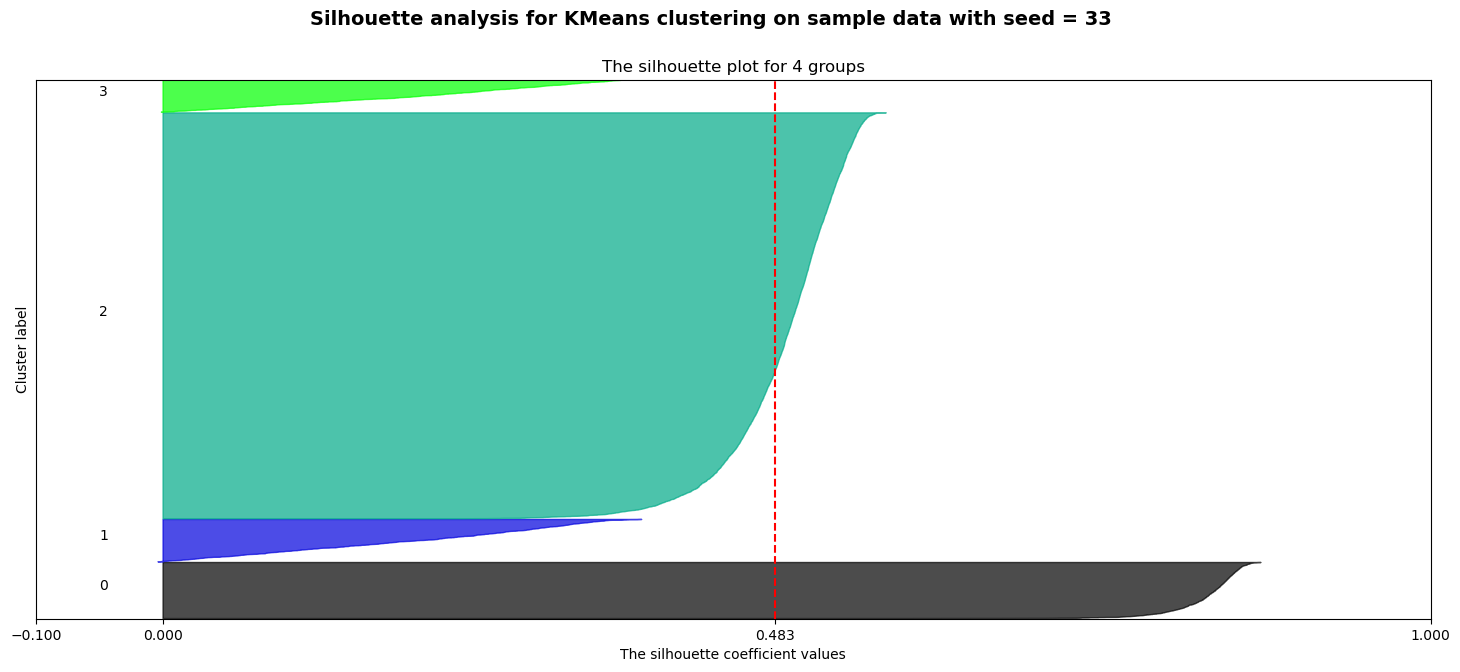

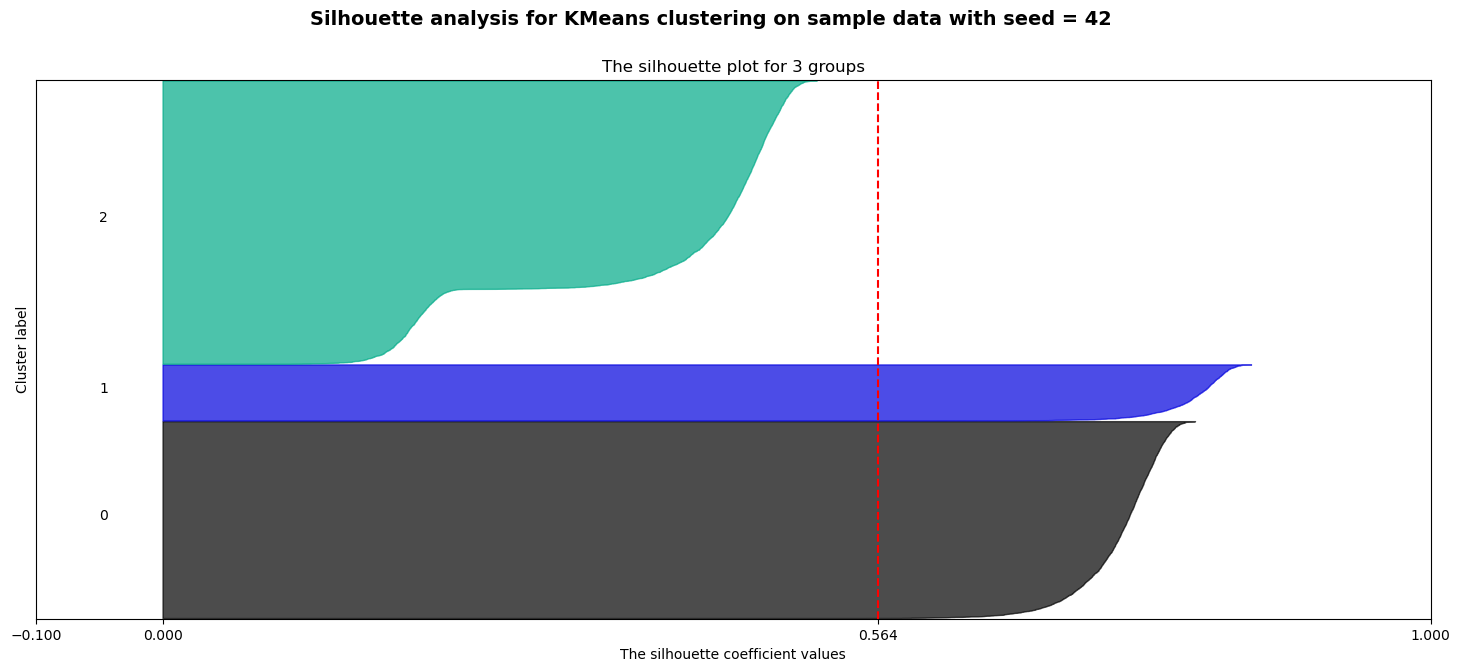

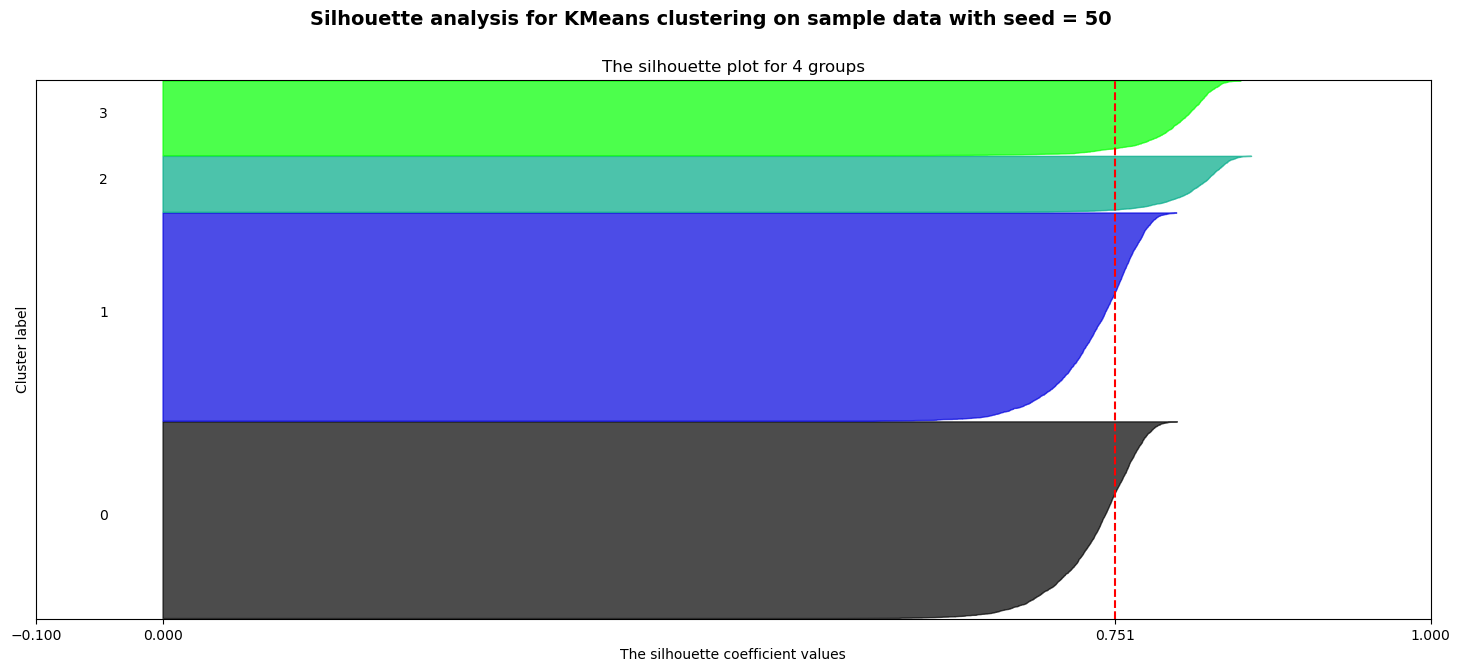

In [25]:
valores = [(9,3),
           (22,4),
           (33,4),
           (42,3),
           (50,4)
           ]

for n, valor in enumerate(valores):
    semilla, k = valor
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(18, 7)
    ax1.set_xlim([-0.1, 0.2])
    ax1.set_ylim([0, len(scaled_df) + (n + 1) * 10])

    clusterer = KMeans(n_clusters=k, random_state=semilla, init='random', n_init=1)
    cluster_labels = clusterer.fit_predict(scaled_df)


    silhouette_avg = silhouette_score(scaled_df, cluster_labels)

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(scaled_df, cluster_labels)

    y_lower = 10
    for i in range(k):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / 5)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title(f"The silhouette plot for {k} groups")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, silhouette_avg, 1.0])

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with seed = %d"
        % semilla,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

## 2.3. Representación Visual

Ahora vamos a dibujar una representación visual de los datos, para ver cómo nuestros algoritmo de K-means está realizando la agrupación.

In [29]:
def plot_model(k, semilla):
    model = KMeans(n_clusters=k,random_state=semilla, init='random', n_init=1)
    model.fit(scaled_df)
    label = model.labels_

    pca = IncrementalPCA(n_components=2, whiten=True)
    x_plot = pca.fit_transform(scaled_df)

    colors = ['gold','red','blue','green']
    colors = dict(zip(range(k), colors))

    plt.scatter(x=x_plot[:,0], y=x_plot[:,1], c=[colors.get(x) for x in label])
    plt.title(f'Grupos para la semilla {semilla} con k={k}')

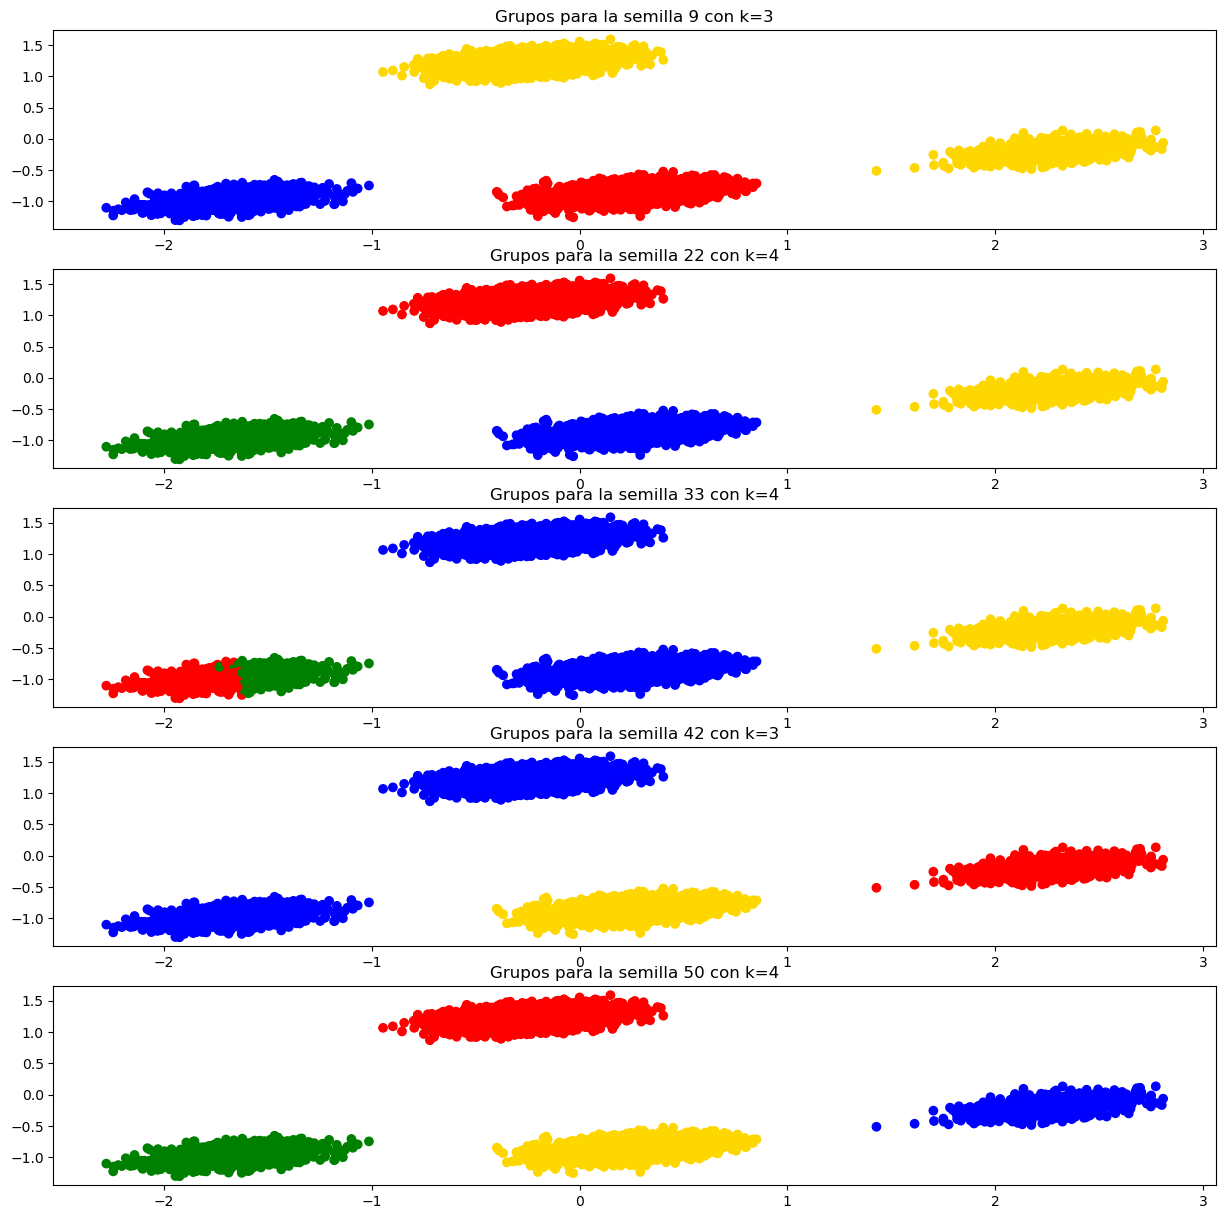

In [31]:
fig = plt.figure(figsize=(15, 15))

for i, valor in enumerate(valores):
    semilla, k = valor
    ax = plt.subplot(len(valores), 1, i + 1)
    plot_model(k, semilla)

plt.show()

Con los candidatos que seleccionamos de las gráficas anteriores, vamos a realizar una agrupación de cada uno de ellos para ver que tanto difieren nuestros modelos.

# 3. Resultados

Definitivamente nuestro modelo debe tener un k=4. Pues nos damos cuenta que genera las mejores agrupaciones. Ahora escogemos el k y la semilla que vamos a usar:




In [33]:
k = 4
semilla = 22

final_model = KMeans(n_clusters=k, random_state=semilla, init='random', n_init=1)
final_model.fit(scaled_df)

KMeans(init='random', n_clusters=4, n_init=1, random_state=22)

Y con nuestro modelo final, podemos determinar los centroides seleccionados por cada grupo

In [35]:
clusters = final_model.cluster_centers_

info_clusters = pd.DataFrame(clusters, index=[f"Grupo {i+1}" for i in range(k)], columns=scaled_df.columns).transpose()
info_clusters

,Grupo 1,Grupo 2,Grupo 3,Grupo 4
BALANCE,-0.940560,0.130989,-0.798496,0.451257
BALANCE_FREQUENCY,0.490628,0.828544,-0.197437,-0.217871
PURCHASES,-0.361819,0.766370,-0.092334,-1.851960
ONEOFF_PURCHASES,0.001436,-0.895382,0.148455,0.014174
INSTALLMENTS_PURCHASES,-0.022161,0.560940,-0.488068,0.006830
CASH_ADVANCE,-0.401496,0.704844,-0.331086,0.090975
PURCHASES_FREQUENCY,-0.807436,0.792946,-0.213877,0.024926
ONEOFF_PURCHASES_FREQUENCY,0.666054,-0.770296,0.084903,0.425772
PURCHASES_INSTALLMENTS_FREQUENCY,-1.447360,-0.245028,0.778037,0.118131
CASH_ADVANCE_FREQUENCY,0.458878,0.053812,-0.935753,0.053325


Veamos la distribución de nuestros clientes con respecto a los cuatro grupos, además podemos tener el número exacto de clientes en cada clúster accediendo a `indexes` y `values`:

([<matplotlib.axis.XTick at 0x23734104b10>,
 [Text(0, 0, '0'), Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3')])

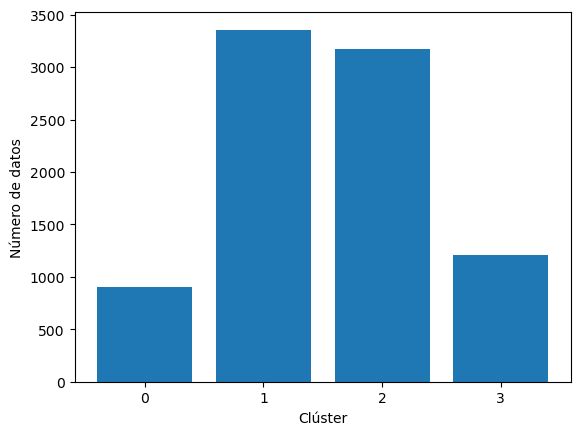

In [37]:
labels = final_model.labels_
indexes, values = np.unique(labels, return_counts=True)
rects = plt.bar(indexes, values)
plt.xlabel('Clúster')
plt.ylabel('Número de datos')
plt.xticks(indexes)

In [39]:
{indexes[i]: values[i] for i in range(len(indexes))}

{0: 903, 1: 3356, 2: 3171, 3: 1206}

Pero esto no dice mucho... demos interpretación a cada uno de los centroides.


## 3.1. Interpretación de centroides

In [41]:
robust_scaler = joblib.load('robust_scaler.joblib')
type(robust_scaler)

sklearn.preprocessing._data.RobustScaler

In [43]:
centroids_array = final_model.cluster_centers_
centroids_original = robust_scaler.inverse_transform(centroids_array)
centroids = pd.DataFrame(centroids_original, columns=data.columns)
centroids

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,3105.917172,0.583910,26323.521692,31054.681489,10485.803990,9355.103901,0.206352,0.797868,0.178405,1.314128,29.837209,284.805094,26109.000090,43726.525314,17429.339551,0.723273,10.598007
1,13252.473365,0.775734,40656.032468,6132.662569,19462.256862,37231.770958,0.797725,0.227979,0.534946,0.990844,92.581049,206.825089,14534.185216,8548.249145,58146.385395,0.363650,9.859058
2,4451.126307,0.193317,29747.057865,35140.273594,3313.474410,11129.239338,0.425684,0.567289,0.838328,0.201070,80.939451,85.725008,15523.980921,24623.728686,32951.234081,0.837494,6.363923
3,16285.111896,0.181718,7392.765979,31408.672313,10932.107057,21763.987743,0.513926,0.702533,0.642639,0.990455,52.631841,166.533167,4386.390604,20649.435423,55187.141515,0.149516,7.826700


Podemos interpretar los centroides de la siguiente forma:

- **Clúster 0 (903 clientes):** Este segmento se caracteriza por tener un balance bajo, con una frecuencia de actualización del balance relativamente alta. Este grupo se caracteriza por tener una muy baja frecuencia de compra (variable `PURCHASES_FREQUENCY`), pero donde la mayoría de sus compras son a una cuota (variable `ONEOFF_PURCHASES_FREQUENCY`) y la mayoría de sus avances son en efectivo. Además, son el grupo con la mayor duración en términos de meses como cliente.

- **Clúster 1 (3356 clientes):** Este segmento de clientes presenta un balance alto, así como una frecuencia de actualización del balance alta, es un grupo con bajas compras a una sola cuota pero con la frecuencia de compra más alta a comparación de los demás grupos. Llevan bastante tiempo como clientes y es el grupo que más hace avances en efectivo.

- **Clúster 2 (3171 clientes):** Este segmento de clientes se caracteriza por tener el balance más bajo y la frecuencia de actualización del balance más bajo. Sin embargo, es el grupo que más compras hace a una sola cuota, por ende, el que menos se endeuda. Es el grupo que menos avances hace en efectivo y el que menos tiempo lleva como cliente.

- **Clúster 3 (1206 clientes):** Este segmento de clientes presenta el balance más alto, pero la menor frecuencia de actualización del balance. Es el grupo que menos compras hace y el que tiene el límite de crédito más bajo dado a que es el grupo que menos cumple con sus respectivos saldos de cuenta mensual.

## 3.2. Visualización Boxplot

In [45]:
scaled_df_original = robust_scaler.inverse_transform(scaled_df)
scaled_df_original = pd.DataFrame(scaled_df_original, columns=data.columns)
scaled_df_original['Grupo'] = [f"Grupo {i+1}" for i in final_model.labels_]

In [47]:
scaled_df_original

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Grupo
0,5323.148883,0.250693,26344.072201,38237.442525,3727.113162,15708.239684,0.496536,0.464442,0.821611,0.194502,100.0,77.0,16819.480037,21337.027458,39452.958121,0.817907,7.0,Grupo 3
1,12726.638115,0.791307,37958.519019,5690.742440,18733.810964,38284.354433,0.699457,0.250327,0.654863,1.083902,78.0,156.0,15617.570575,8000.183624,63013.748477,0.343119,9.0,Grupo 2
2,4740.988511,0.178076,27399.003842,38246.863491,3402.853375,6936.812518,0.439666,0.606597,0.783129,0.228299,78.0,83.0,12926.587974,23919.113404,38444.219979,0.883984,7.0,Grupo 3
3,13820.920640,0.826914,42214.021633,7341.007821,19273.070991,40091.347849,0.821412,0.283579,0.501361,1.106350,88.0,182.0,14404.705067,6994.688474,62041.617340,0.383186,10.0,Grupo 2
4,12439.064887,0.706673,40674.226116,6156.208831,19401.475615,32438.912698,0.836764,0.343936,0.527813,0.970693,103.0,216.0,14554.911546,8814.239865,58227.564690,0.398377,10.0,Grupo 2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8631,6095.221156,0.234346,27094.007822,35917.204378,3463.821376,11711.578889,0.469832,0.539477,0.828321,0.191030,75.0,101.0,17623.810282,23954.396952,34841.829885,0.866856,7.0,Grupo 3
8632,12682.575822,0.686025,38433.618847,5293.541956,18924.799798,34444.867317,0.710331,0.276426,0.546059,0.935152,95.0,170.0,12433.814929,7375.625322,66726.372993,0.306600,10.0,Grupo 2
8633,16464.311409,0.189136,4296.196384,32554.759639,11231.500433,15214.671563,0.424665,0.746010,0.690380,1.063788,51.0,151.0,3307.587117,22947.759217,54761.962206,0.129242,8.0,Grupo 4
8634,15531.883777,0.117118,12219.325647,31795.971700,12390.432127,13856.393208,0.450670,0.805140,0.608737,1.058548,61.0,178.0,6148.232910,21369.503519,50368.309060,0.087448,8.0,Grupo 4


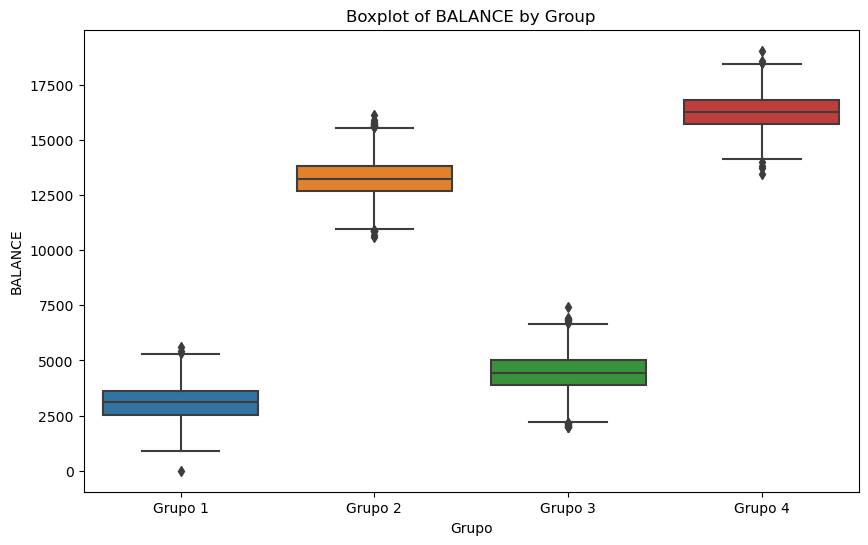

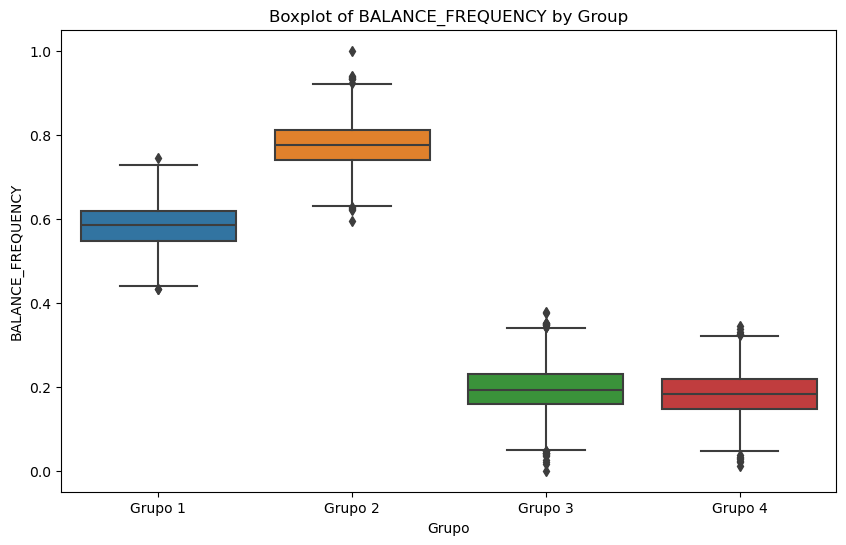

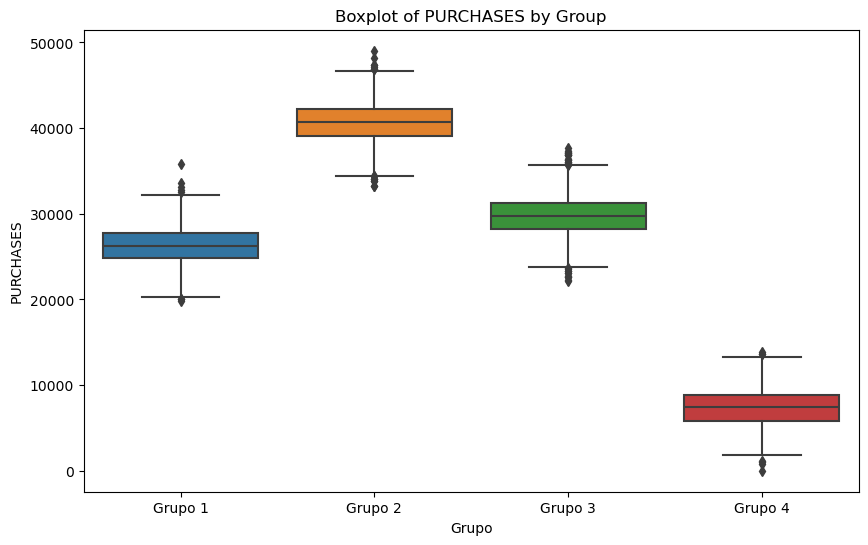

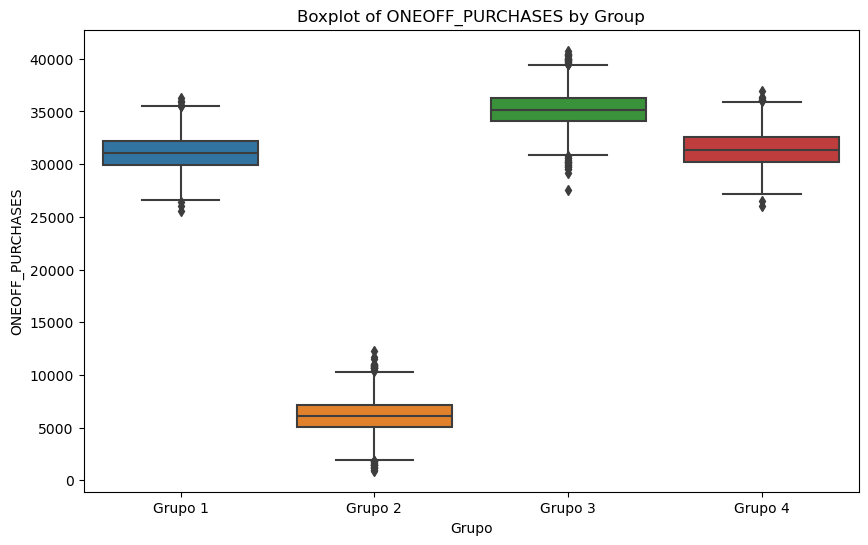

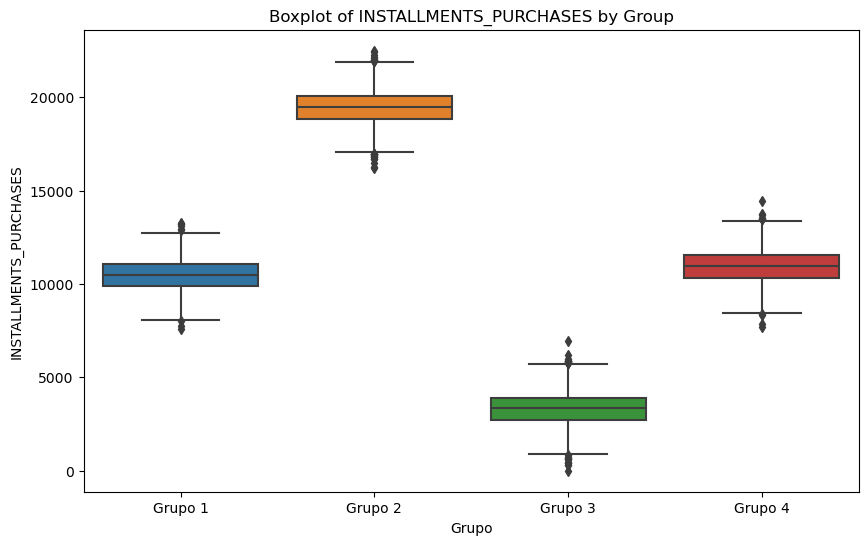

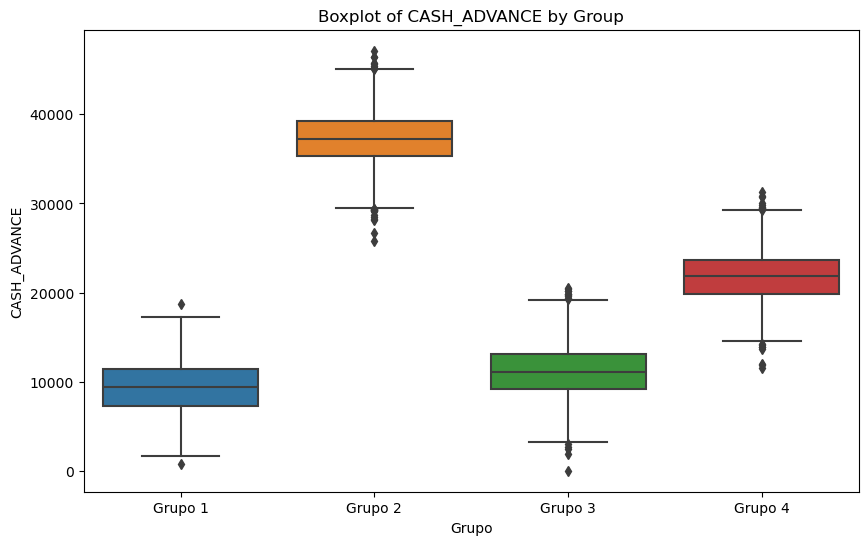

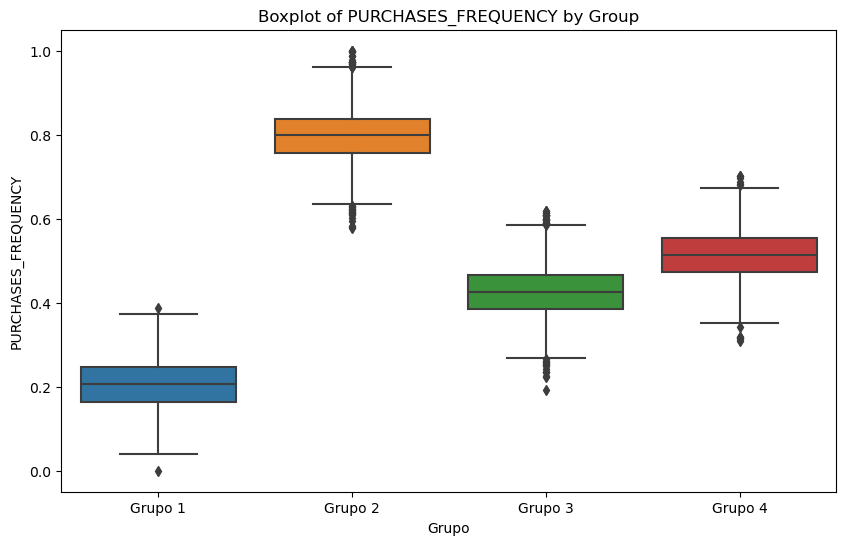

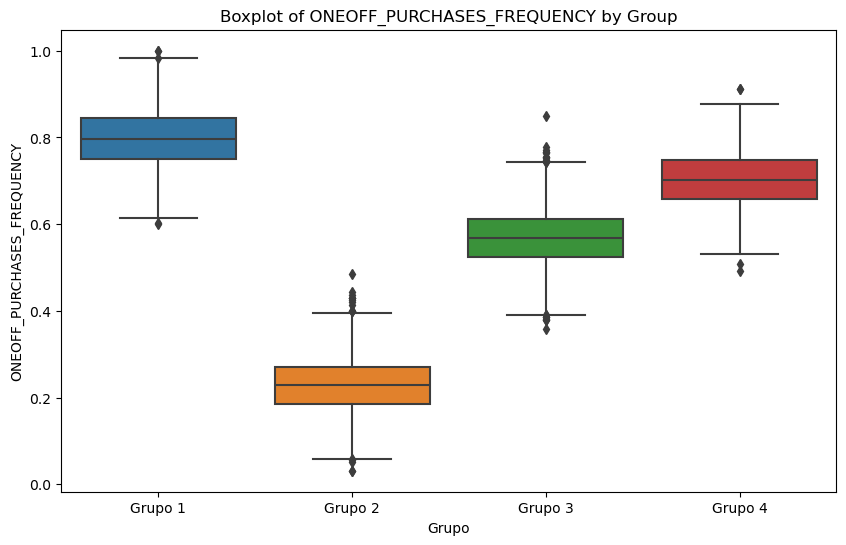

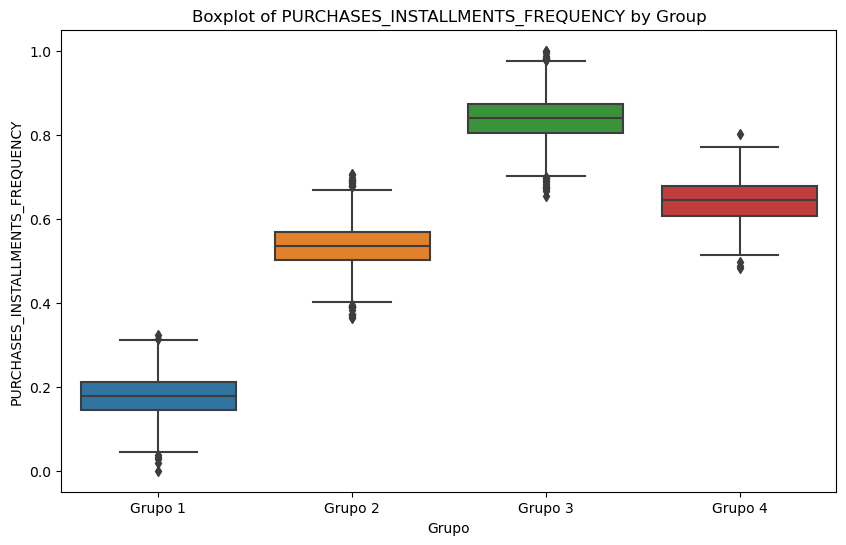

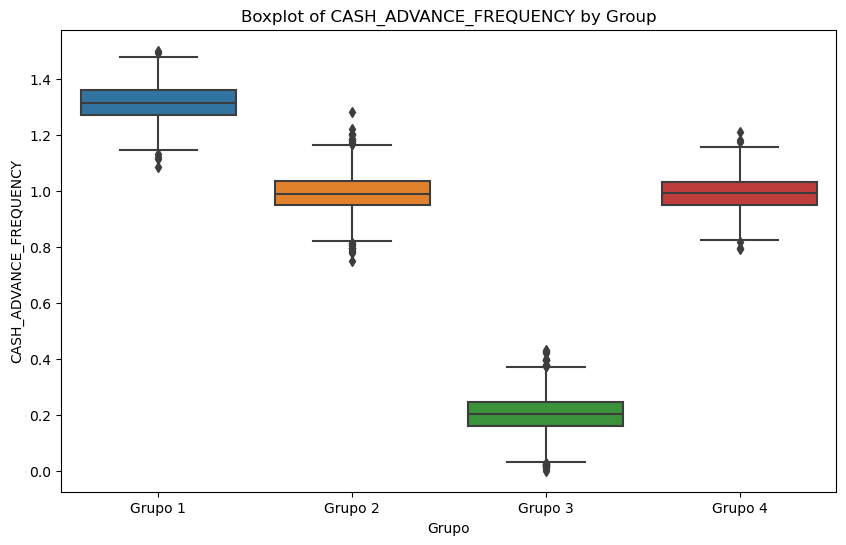

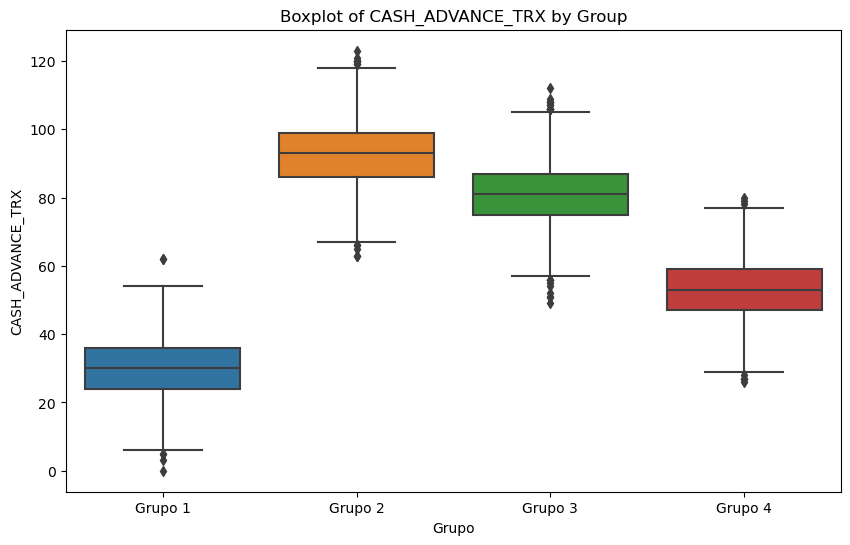

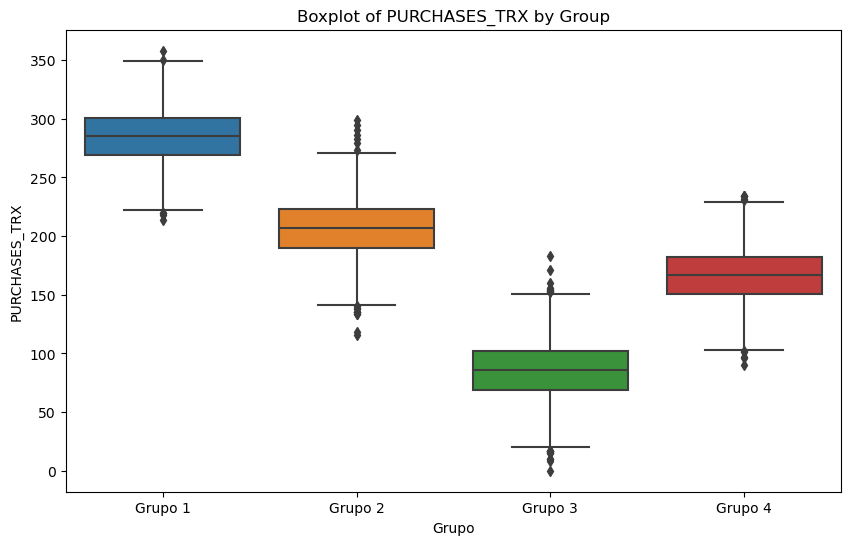

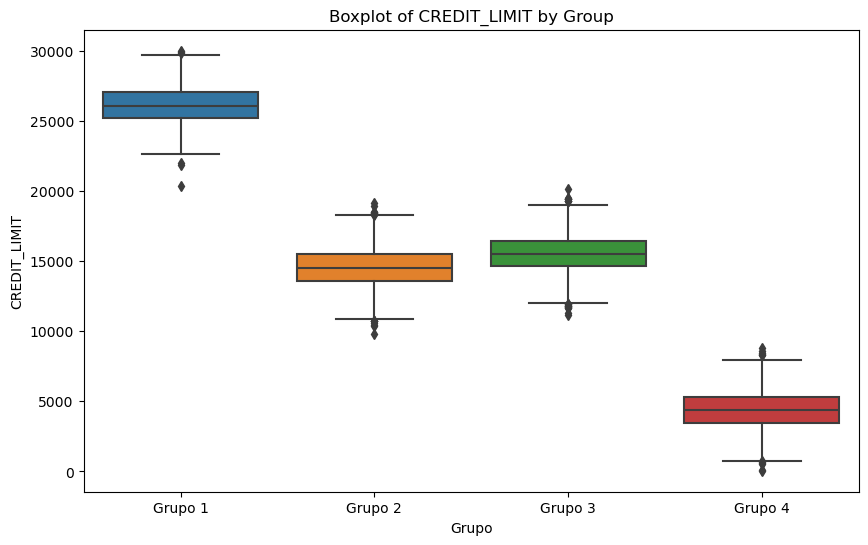

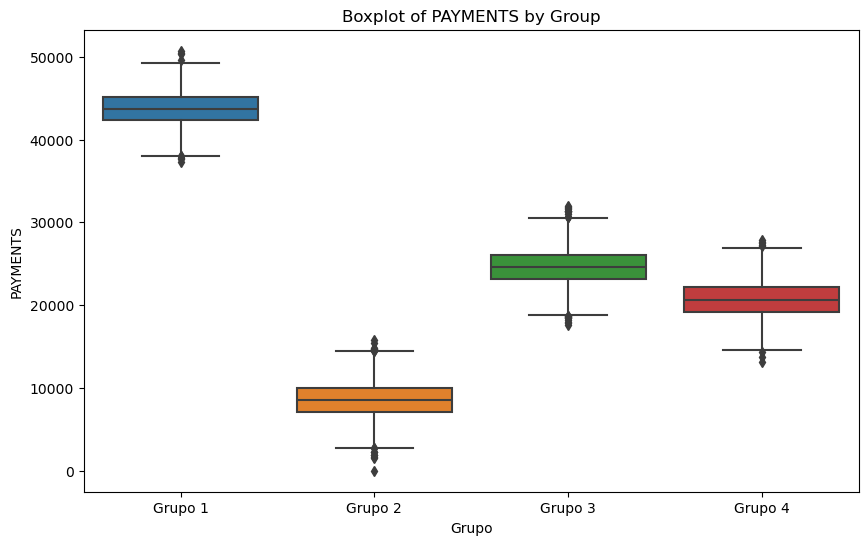

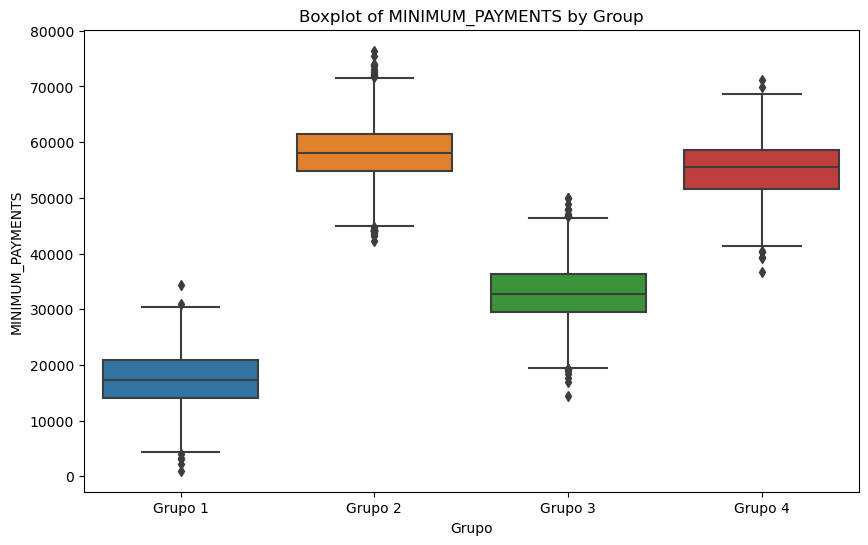

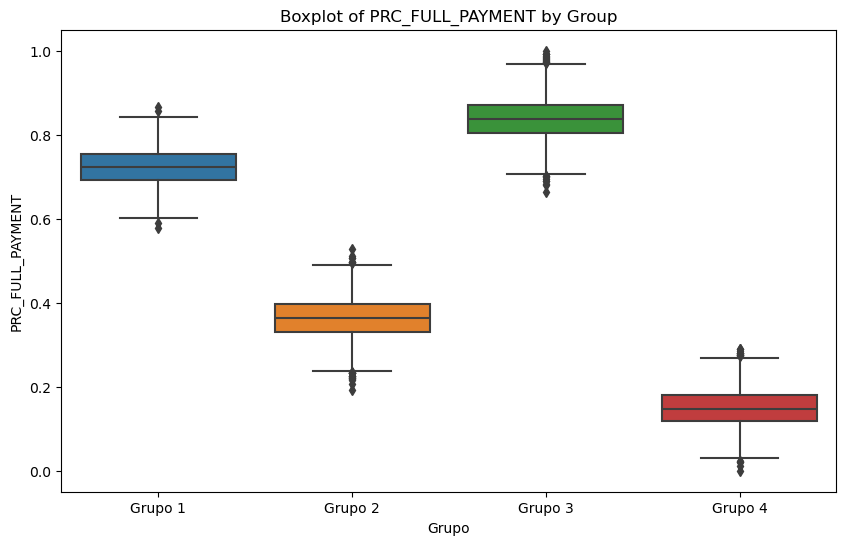

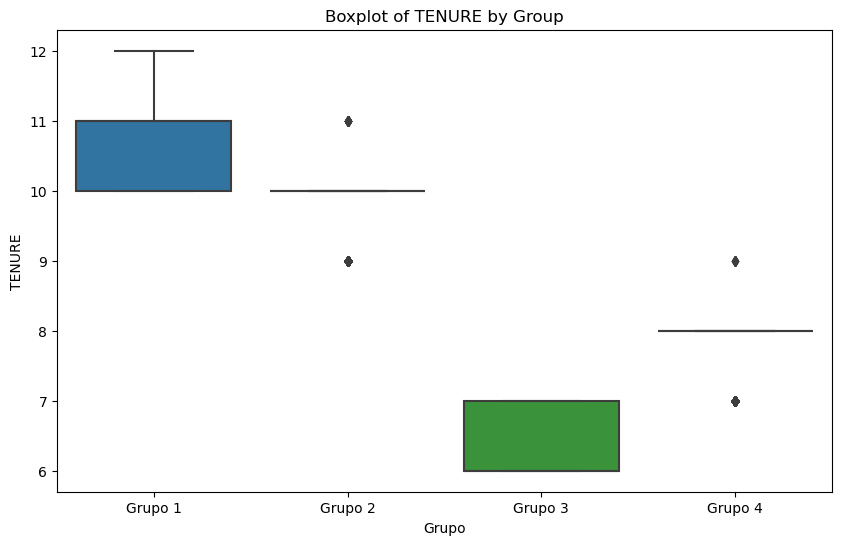

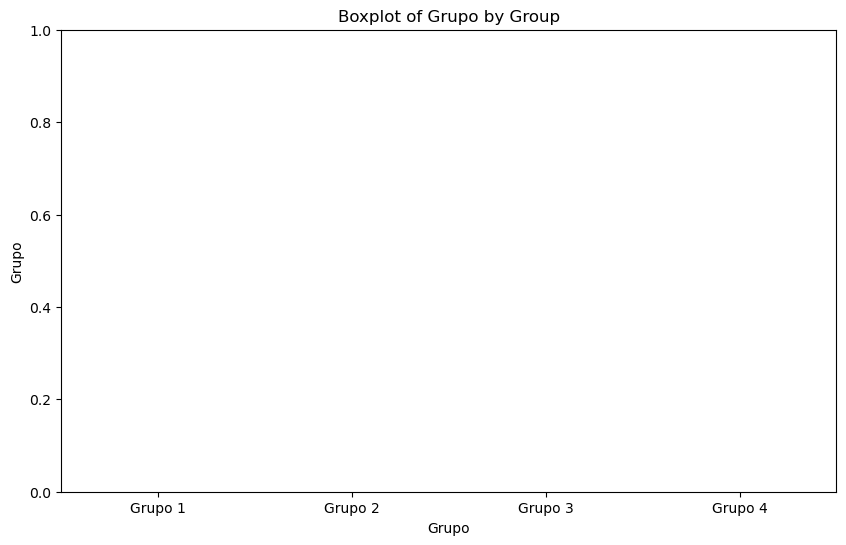

In [49]:
columns = scaled_df_original.columns
df_temp = scaled_df_original.copy()
df_temp['Grupo'] = scaled_df_original['Grupo']

for column in columns:
    df_temp[column] = pd.to_numeric(df_temp[column], errors='coerce')
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Grupo', y=column, data=df_temp, order=['Grupo 1', 'Grupo 2', 'Grupo 3', 'Grupo 4'])
    plt.title(f'Boxplot of {column} by Group')
    plt.show()